## Task 1:-Prepare a complete data analysis report on the given data.

## Task 2:-Create a model to classify the data points into given labels. 


## Importing Required libraries

In [1]:
# Basic data handling
import numpy as np
import pandas as pd

# Visualization (for EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Loading the data set

In [2]:
df = pd.read_csv("tae.csv")

In [3]:
df

,TA,Instructor,Course,semester,Class size,Class attribute,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,1,23,3,1,19,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,15,3,1,17,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,23,3,2,49,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,5,2,2,33,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,7,11,2,55,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2,3,2,2,26,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,2,10,3,2,12,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,1,18,7,2,48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,2,22,1,2,51,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')] # Removing the unwanted coloumns 


In [5]:
df

,TA,Instructor,Course,semester,Class size,Class attribute
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3
...,...,...,...,...,...,...
146,2,3,2,2,26,1
147,2,10,3,2,12,1
148,1,18,7,2,48,1
149,2,22,1,2,51,1


# Basic Checks

In [6]:
df.head()

,TA,Instructor,Course,semester,Class size,Class attribute
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3


In [7]:
df.tail()

,TA,Instructor,Course,semester,Class size,Class attribute
146,2,3,2,2,26,1
147,2,10,3,2,12,1
148,1,18,7,2,48,1
149,2,22,1,2,51,1
150,2,2,10,2,27,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   TA               151 non-null    int64
 1   Instructor       151 non-null    int64
 2   Course           151 non-null    int64
 3    semester        151 non-null    int64
 4   Class size       151 non-null    int64
 5   Class attribute  151 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


In [9]:
df.describe()

,TA,Instructor,Course,semester,Class size,Class attribute
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,1.807947,13.642384,8.105960,1.847682,27.867550,2.019868
std,0.395225,6.825779,7.023914,0.360525,12.893758,0.820327
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,8.000000,3.000000,2.000000,19.000000,1.000000
50%,2.000000,13.000000,4.000000,2.000000,27.000000,2.000000
75%,2.000000,20.000000,15.000000,2.000000,37.000000,3.000000
max,2.000000,25.000000,26.000000,2.000000,66.000000,3.000000


In [10]:
df.shape

(151, 6)

In [11]:
df.isnull().sum()


TA                 0
Instructor         0
Course             0
 semester          0
Class size         0
Class attribute    0
dtype: int64

In [12]:
df.duplicated().sum()


41

In [13]:
df['Class attribute'].value_counts()


Class attribute
3    52
2    50
1    49
Name: count, dtype: int64

In [14]:
df.corr()


,TA,Instructor,Course,semester,Class size,Class attribute
TA,1.000000,-0.250510,0.134660,0.214417,-0.151547,-0.255466
Instructor,-0.250510,1.000000,-0.236010,-0.168573,-0.035765,0.075095
Course,0.134660,-0.236010,1.000000,0.224927,-0.033485,0.143103
semester,0.214417,-0.168573,0.224927,1.000000,0.269554,-0.282742
Class size,-0.151547,-0.035765,-0.033485,0.269554,1.000000,-0.035676
Class attribute,-0.255466,0.075095,0.143103,-0.282742,-0.035676,1.000000


# Domain Analysis

## TAE - Teaching Assistance Evaluation

* The data consist of performance/evaluation of teaching over three regular semesters and two summer semesters of 151 teaching assistant (TA) assignments at the Statistics Department of the University of Wisconsin-Madison.

* This dataset explains about evaluating a teachers performance based on many factors such as
* 1)  Whether the teacher is an english speaker or not
  2)  What type of course they take
  3)  How many types of courses are there
  4)  whether it is a regular sem or summer sem
  5)  Number of students in a class
* Here we are trying to evaluate the teacher's performance based on the above factors.


# Problem Definition

* The task here to is to classify the score or performance of the teacher
* The performance is classified into 3 classes
* 1) Low score
  2) medium score
  3) high score

## EDA - Exploratory Data Analysis


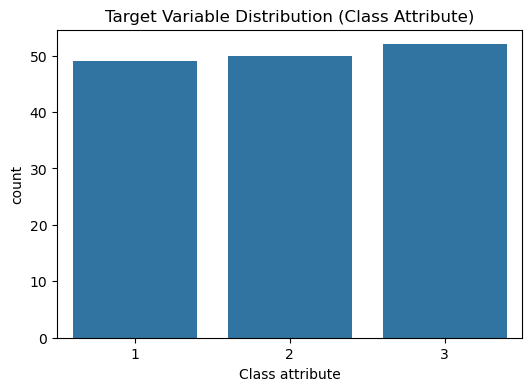

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Class attribute"])
plt.title("Target Variable Distribution (Class Attribute)")
plt.show()

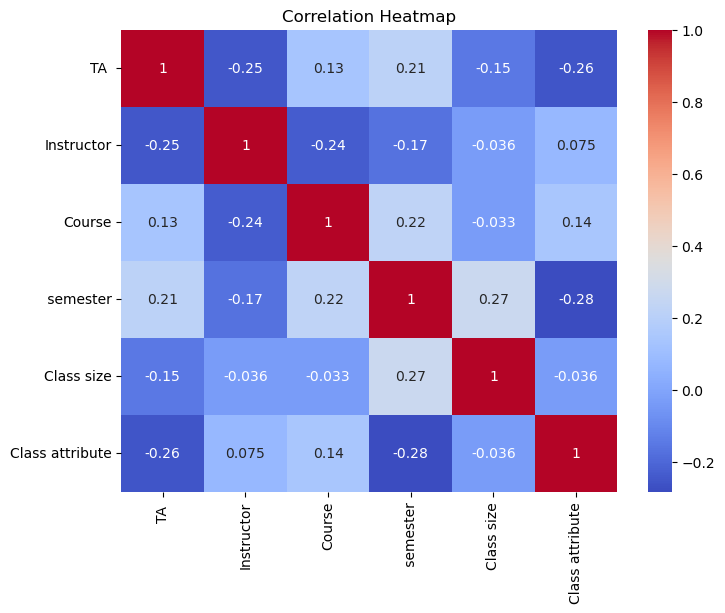

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

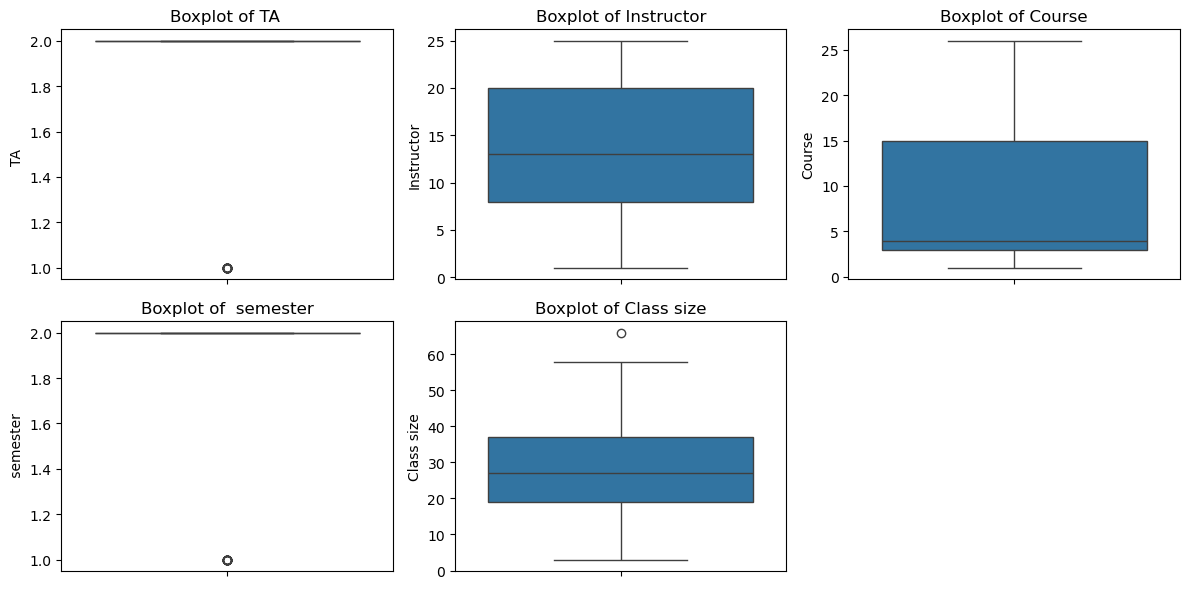

In [18]:
numeric_cols = df.columns[:-1]
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

<Axes: ylabel='None'>

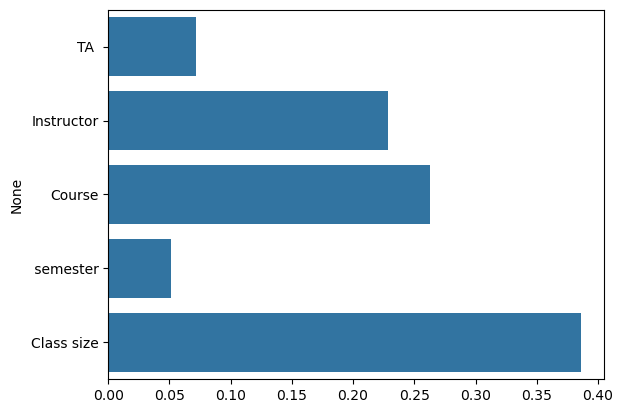

In [48]:
import seaborn as sns

importances = rf.feature_importances_
sns.barplot(x=importances, y=X.columns)


## EDA Report
* There are no missing values
* No outliers

# Data Preprocessing

### Splitting the data into input and output

In [19]:
# Split features and target
X = df.drop("Class attribute", axis=1)
y = df["Class attribute"]

In [21]:
X

,TA,Instructor,Course,semester,Class size
0,1,23,3,1,19
1,2,15,3,1,17
2,1,23,3,2,49
3,1,5,2,2,33
4,2,7,11,2,55
...,...,...,...,...,...
146,2,3,2,2,26
147,2,10,3,2,12
148,1,18,7,2,48
149,2,22,1,2,51


In [22]:
y

0      3
1      3
2      3
3      3
4      3
      ..
146    1
147    1
148    1
149    1
150    1
Name: Class attribute, Length: 151, dtype: int64

## Train-Test Split

In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
X_train

,TA,Instructor,Course,semester,Class size
15,2,6,17,2,43
125,1,13,1,2,54
11,2,13,1,2,30
127,2,20,2,2,45
51,2,18,21,2,29
...,...,...,...,...,...
71,2,13,1,2,31
106,2,23,3,2,10
14,2,6,17,2,42
92,2,18,25,2,25


In [25]:
X_test

,TA,Instructor,Course,semester,Class size
76,2,5,2,2,48
18,2,13,3,1,10
82,2,13,3,1,11
81,2,9,2,2,39
143,2,3,2,2,37
31,2,18,5,2,19
78,1,23,3,1,25
64,2,7,11,2,13
55,2,7,11,2,10
85,2,7,11,1,20


In [26]:
y_train

15     2
125    3
11     3
127    3
51     3
      ..
71     1
106    2
14     2
92     3
102    2
Name: Class attribute, Length: 120, dtype: int64

In [27]:
y_test

76     1
18     2
82     3
81     3
143    1
31     1
78     3
64     2
55     2
85     3
45     3
12     3
36     1
9      3
19     2
137    2
114    1
146    1
56     2
133    2
29     1
84     3
26     2
132    2
124    3
142    1
111    1
67     1
98     2
30     1
22     2
Name: Class attribute, dtype: int64

## Model Selection


### Model building

We are starting with Logistic Regression model 


## LOGISTIC REGRESSION MODEL

In [28]:
#Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [29]:
y_pred_lr = log_reg.predict(X_test)

In [30]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5806451612903226


In [31]:
# Generate classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred_lr))


Classification Report:

              precision    recall  f1-score   support

           1       0.53      0.73      0.62        11
           2       0.50      0.45      0.48        11
           3       0.83      0.56      0.67         9

    accuracy                           0.58        31
   macro avg       0.62      0.58      0.59        31
weighted avg       0.61      0.58      0.58        31



# Model Performance

* The accuracy of the model is 58% which is bad
* This happens because the data set is small and non linear
* Logistic Regression estimates the probability that a given input belongs to a particular class by applying a linear model and transforming its output through a logistic function.
* Our data is based on classification data.
* We will try with other models for better accuracy.

# DECISION TREE CLASSIFIER

In [32]:
# Train Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)


DecisionTreeClassifier()

In [33]:
y_pred_dt = dt.predict(X_test)

In [34]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6774193548387096


In [35]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


[[9 1 1]
 [2 7 2]
 [1 3 5]]
              precision    recall  f1-score   support

           1       0.75      0.82      0.78        11
           2       0.64      0.64      0.64        11
           3       0.62      0.56      0.59         9

    accuracy                           0.68        31
   macro avg       0.67      0.67      0.67        31
weighted avg       0.67      0.68      0.67        31



## Fine Tuning the model

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [2, 3, 4, 5, 6, None],
    'min_samples_split': [2, 3, 4, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}


In [38]:
dt = DecisionTreeClassifier()

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3, 4],
                         'min_samples_split': [2, 3, 4, 5, 10]},
             scoring='accuracy')

In [39]:
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Best parameters: {'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 10}
Best score: 0.6166666666666667


In [40]:
best_dt = grid_search.best_estimator_

y_pred_best = best_dt.predict(X_test)

print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


Tuned Decision Tree Accuracy: 0.45161290322580644
              precision    recall  f1-score   support

           1       0.47      0.64      0.54        11
           2       0.38      0.27      0.32        11
           3       0.50      0.44      0.47         9

    accuracy                           0.45        31
   macro avg       0.45      0.45      0.44        31
weighted avg       0.44      0.45      0.44        31



## Model Perforance

* The decision tree model performance is not that good
* It's accuracy before fine tuning was 67%
* After fine tuning with the help of Grid search CV, It still has not given the best accuracy
* That is understandable, because the model is working with a small data set of 150 rows and 6 coloumns and there is more categorical data than numerical data.
* So, decision trree classifier is not the best model for the data set.
* We will be trying the Random Forest classifier model next.
  

# Random Forest Classifier

In [41]:
# Build Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [42]:
# Train on training data
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [43]:
# Predictions
y_pred_rf = rf.predict(X_test)

In [44]:
# Accuracy
acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc)

Random Forest Accuracy: 0.7096774193548387


In [45]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))



Confusion Matrix:
[[10  0  1]
 [ 2  7  2]
 [ 2  2  5]]


In [46]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Classification Report:
              precision    recall  f1-score   support

           1       0.71      0.91      0.80        11
           2       0.78      0.64      0.70        11
           3       0.62      0.56      0.59         9

    accuracy                           0.71        31
   macro avg       0.71      0.70      0.70        31
weighted avg       0.71      0.71      0.70        31



### Hyper parameter tuning

In [49]:
# Parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"]
}

In [50]:
# Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(n_estimators=200,
                                              random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=2)

In [51]:
# Best parameters
print("Best Parameters:", grid.best_params_)


Best Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [52]:
# Best model
best_rf = grid.best_estimator_


In [53]:
# Predictions
y_pred = best_rf.predict(X_test)


In [54]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7096774193548387


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.71      0.91      0.80        11
           2       0.78      0.64      0.70        11
           3       0.62      0.56      0.59         9

    accuracy                           0.71        31
   macro avg       0.71      0.70      0.70        31
weighted avg       0.71      0.71      0.70        31

